In [2]:
!pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
    --------------------------------------- 0.5/40.2 MB 2.1 MB/s eta 0:00:20
    --------------------------------------- 0.8/40.2 MB 1.8 MB/s eta 0:00:23
   - -------------------------------------- 1.0/40.2 MB 1.9 MB/s eta 0:00:22
   - -------------------------------------- 1.3/40.2 MB 1.4 MB/s eta 0:00:28
   - -------------------------------------- 1.8/40.2 MB 1.5 MB/s eta 0:00:25
   -- ------------------------------------- 2.1/40.2 MB 1.5 MB/s eta 0:00:26
   -- ------------------------------------- 2.1/40.2 MB 1.5 MB/s eta 0:00:26
   -- ------------------------------------- 2.4/40.2 MB 1.4 MB/s eta 0:00:28
   -- ------------------------------------- 2.6/40.2 MB 1.4 MB/s eta 0:00:28
   -- ------------------------------------- 2.9/40.2 MB 1.4 MB/s eta 0:00:28
   --- ------------------------------------ 3.1/40.2 MB 1.4 MB/s eta 0:00:28
   --- ------

In [3]:
# ============================================
# 1. Import Required Libraries
# ============================================
import h5py
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
import cv2   # pip install opencv-python

In [4]:
# ============================================
# 2. Load NEON Hyperspectral Data
# ============================================
file_path = r"E:\NEON.D17.SOAP.DP3.30006.001.2021-07.basic.20260417T085601Z.RELEASE-2026\NEON_D17_SOAP_DP3_299000_4103000_reflectance.h5"

with h5py.File(file_path, 'r') as f:
    site_name = list(f.keys())[0]
    print("Site detected:", site_name)
    
    data_cube = f[site_name]['Reflectance']['Reflectance_Data'][:]
    wavelengths = f[site_name]['Reflectance']['Metadata']['Spectral_Data']['Wavelength'][:]

print("Data dimensions:", data_cube.shape)

Site detected: SOAP
Data dimensions: (1000, 1000, 426)


In [5]:
# ============================================
# 3. Clean Data (Remove NoData)
# ============================================
data_cube = data_cube.astype(float)
data_cube[data_cube == -9999] = np.nan

In [6]:
# ============================================
# 4. Extract Pixel Spectrum
# ============================================
r, c = 100, 100
spectrum = data_cube[r, c, :]


In [7]:
# Keep useful wavelength range
mask_valid = (wavelengths > 400) & (wavelengths < 1800)

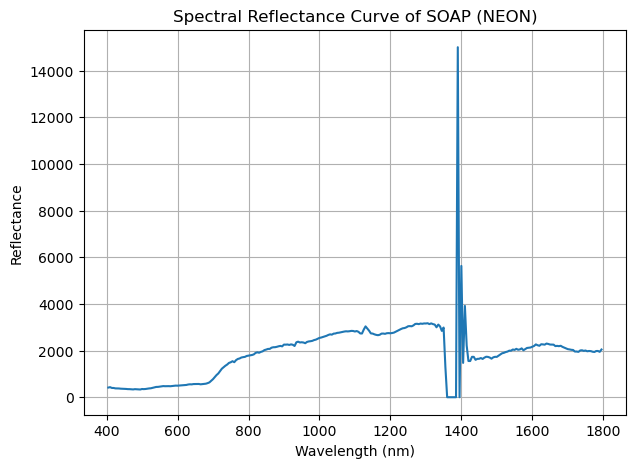

In [20]:
# ============================================
# 5. Plot Original Spectral Curve
# ============================================
plt.figure(figsize=(7,5))
plt.plot(wavelengths[mask_valid], spectrum[mask_valid])
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectral Reflectance Curve of SOAP (NEON)")
plt.grid()
plt.show()

In [9]:
# ============================================
# 6. Noise Removal (Smoothing)
# ============================================
smooth_spec = savgol_filter(spectrum, window_length=21, polyorder=3)

# Remove noisy absorption regions
clean_mask = (
    (wavelengths > 400) & (wavelengths < 1300) |
    (wavelengths > 1450) & (wavelengths < 1800)
)

wl_clean = wavelengths[clean_mask]
spec_clean = smooth_spec[clean_mask]

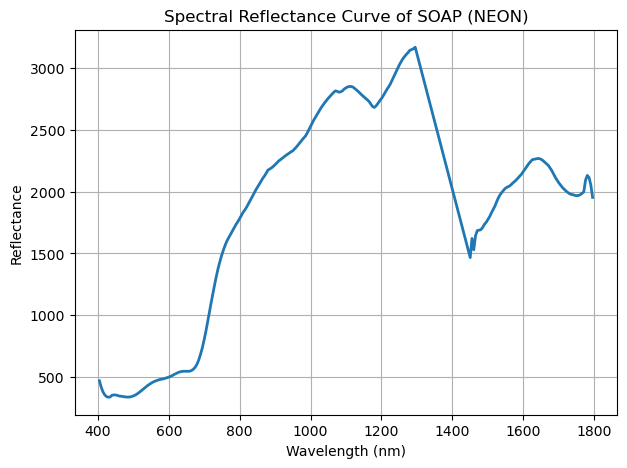

In [22]:
# ============================================
# 7. Plot Clean Spectral Curve
# ============================================
plt.figure(figsize=(7,5))
plt.plot(wl_clean, spec_clean, linewidth=2)
plt.xlabel("Wavelength (nm)")
plt.ylabel("Reflectance")
plt.title("Spectral Reflectance Curve of SOAP (NEON)")
plt.grid()
plt.show()

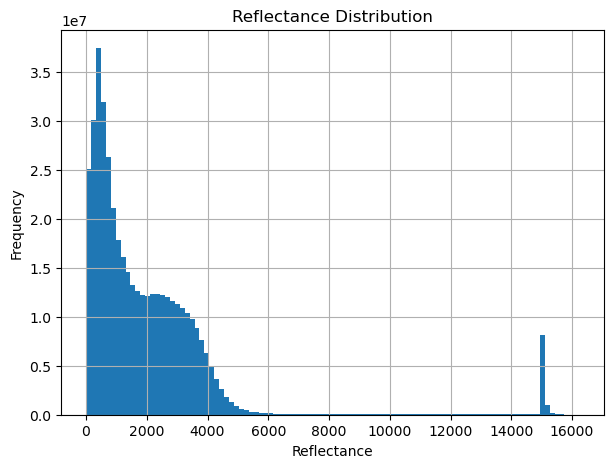

In [11]:
# ============================================
# 8. Histogram of Reflectance Values
# ============================================
valid_pixels = data_cube[~np.isnan(data_cube)]

plt.figure(figsize=(7,5))
plt.hist(valid_pixels, bins=100)
plt.xlabel("Reflectance")
plt.ylabel("Frequency")
plt.title("Reflectance Distribution")
plt.grid()
plt.show()


In [12]:
# ============================================
# 9. Band Selection (RGB + NIR)
# ============================================
r_band = np.argmin(np.abs(wavelengths - 660))
g_band = np.argmin(np.abs(wavelengths - 550))
b_band = np.argmin(np.abs(wavelengths - 470))
nir_band = np.argmin(np.abs(wavelengths - 800))


In [13]:
# ============================================
# 10. Contrast Stretch Function
# ============================================
def contrast_stretch(img):
    low, high = np.nanpercentile(img, (2, 98))
    scaled = (img - low) / (high - low)
    return np.clip(scaled, 0, 1)


In [14]:
# Extract and normalize bands
R = contrast_stretch(data_cube[:, :, r_band])
G = contrast_stretch(data_cube[:, :, g_band])
B = contrast_stretch(data_cube[:, :, b_band])
NIR = contrast_stretch(data_cube[:, :, nir_band])


In [15]:
# ============================================
# 11. Create Composite Images
# ============================================
rgb_image = np.dstack((R, G, B))
false_color = np.dstack((NIR, R, G))


In [16]:
# Gamma correction
gamma = 0.5
rgb_image = np.power(rgb_image, gamma)
false_color = np.power(false_color, gamma)


In [17]:
# ============================================
# 12. Enhance Image Resolution
# ============================================
def upscale_and_sharpen(img, scale=2):
    h, w, _ = img.shape
    
    # Resize
    resized = cv2.resize(img, (w*scale, h*scale), interpolation=cv2.INTER_CUBIC)
    
    # Sharpen kernel
    kernel = np.array([[0,-1,0],
                       [-1,5,-1],
                       [0,-1,0]])
    
    sharpened = cv2.filter2D(resized, -1, kernel)
    
    return np.clip(sharpened, 0, 1)

rgb_high = upscale_and_sharpen(rgb_image, scale=2)
false_high = upscale_and_sharpen(false_color, scale=2)


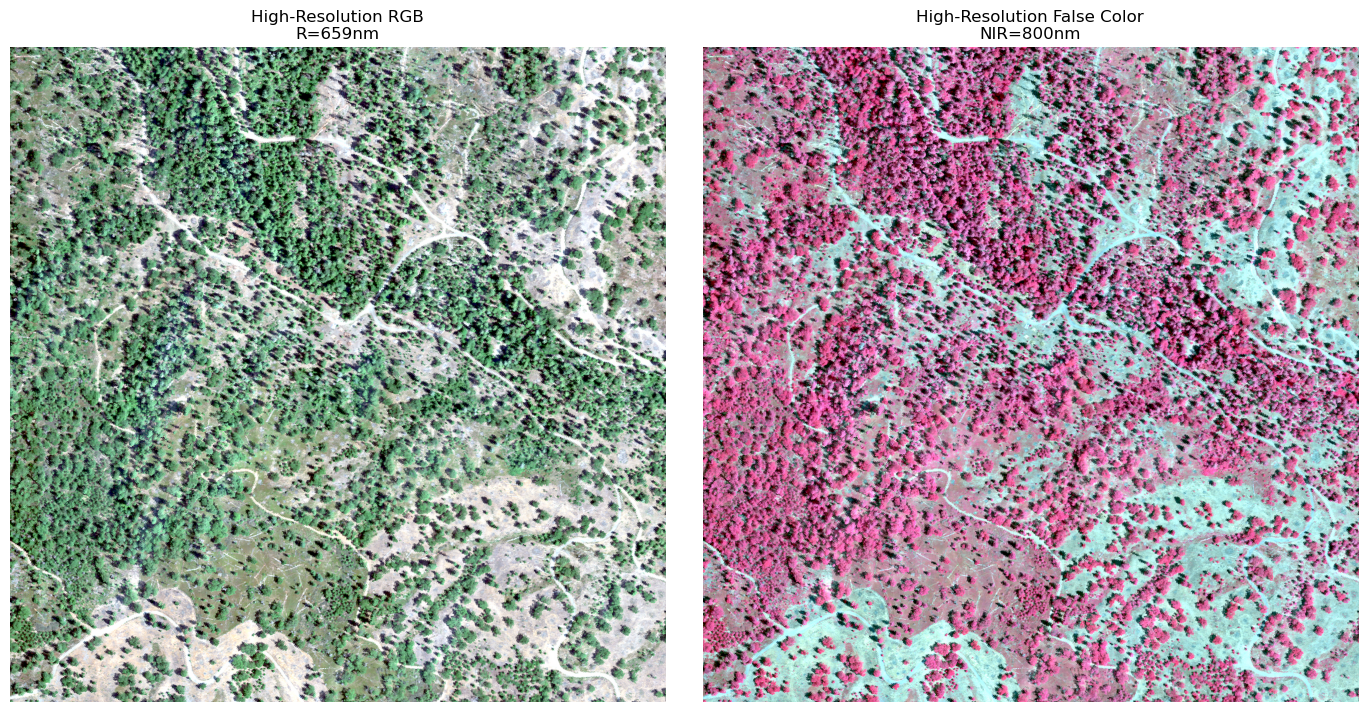

In [18]:
# ============================================
# 13. Display Final Images
# ============================================
plt.figure(figsize=(14,7))

plt.subplot(1,2,1)
plt.imshow(rgb_high)
plt.title(f"High-Resolution RGB\nR={wavelengths[r_band]:.0f}nm")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(false_high)
plt.title(f"High-Resolution False Color\nNIR={wavelengths[nir_band]:.0f}nm")
plt.axis('off')

plt.tight_layout()
plt.show()